In [134]:
import rasterio
import numpy
import matplotlib.pyplot as plt
from pathlib import Path
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.patches import Patch
import torch
import segmentation_models_pytorch as smp


s1_path = Path("data/S1Hand/Bolivia_103757_S1Hand.tif")
label_path = Path("data/LabelHand/Bolivia_103757_LabelHand.tif")

In [135]:
#Read in GeoTIFF files as rastser and read vv,vh and label
with rasterio.open(s1_path) as s1_img:
    vv = s1_img.read(1)
    vh = s1_img.read(2)

with rasterio.open(label_path) as label_img:
    label = label_img.read(1)

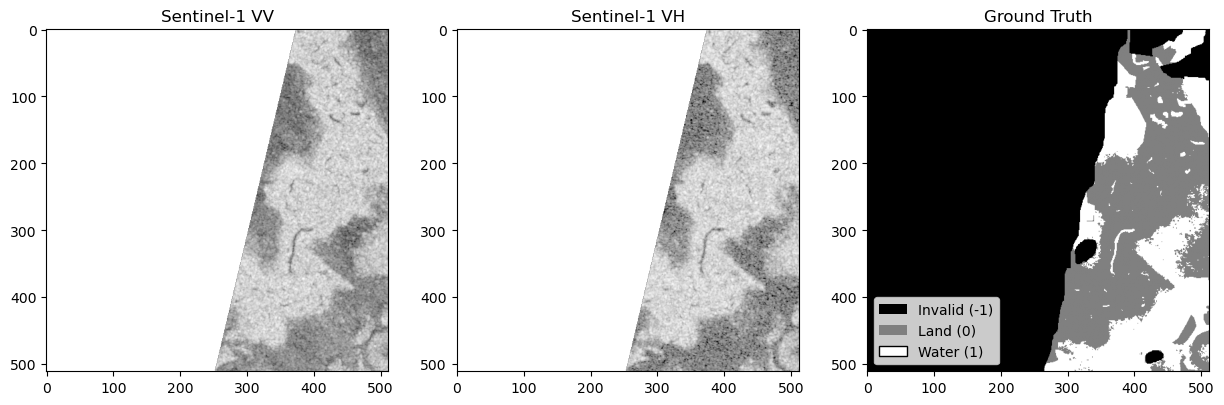

In [136]:
#show the images of vv, vh and groundtruth for the first time (with legend)
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(vv, cmap="gray")
axes[0].set_title("Sentinel-1 VV")

axes[1].imshow(vh, cmap="gray")
axes[1].set_title("Sentinel-1 VH")

axes[2].imshow(label, cmap="gray", vmin=-1, vmax=1)
axes[2].set_title("Ground Truth")

legend_elements = [
    Patch(facecolor="black", label="Invalid (-1)"),
    Patch(facecolor="gray", label="Land (0)"),
    Patch(facecolor="white", edgecolor="black", label="Water (1)")
]

axes[2].legend(handles=legend_elements, loc="lower left")

In [ ]:
# Define the Pixels where both SAR channels and the label are valid (value not infinite and not label -1)
valid_mask = (numpy.isfinite(vv) 
              & numpy.isfinite(vh) 
              & numpy.isin(label, [0, 1]))


# Normalization of the raw SAR values (radiation) by using the z-score normalization
def normalize_channel(channel, valid_mask):
    values = channel[valid_mask]

    mean = values.mean()
    std = values.std()

    normalized = (channel - mean) / max(std, 1e-6)

    # Replace NaN and infinity with zero
    normalized = numpy.nan_to_num(
        normalized,
        nan=0.0,
        posinf=0.0,
        neginf=0.0)

    # Set all invalid pixels to zero
    normalized[~valid_mask] = 0

    return normalized.astype(numpy.float32)


vv_normalized = normalize_channel(vv, valid_mask)
vh_normalized = normalize_channel(vh, valid_mask)

# Combine vv and vh into one 2-channel-image
input_image = numpy.stack([vv_normalized, vh_normalized], axis=0)

In [ ]:
# Prepare data for PyTorch with tensor and adding another dimension with unsqueeze
water_pixel = (label == 1).astype(numpy.float32)

image_tensor = torch.from_numpy(input_image)
target_tensor = torch.from_numpy(water_pixel).unsqueeze(0)
valid_tensor = torch.from_numpy(valid_mask.astype(numpy.float32)).unsqueeze(0)

# Create U-net
model = smp.Unet(
    encoder_name="resnet18",
    encoder_weights=None,
    in_channels=2,
    classes=1)

In [ ]:
# Add a fourth dimension (n of images, channels, height/width)
x = image_tensor.unsqueeze(0)

model.eval()

with torch.no_grad():
    prediction = model(x)

# Convert raw model output (logits) to probabilities
probabilities = torch.sigmoid(prediction)

# Remove batch and channel dimensions
prob_map = probabilities.squeeze().numpy()

pred_mask = (prob_map >= 0.5).astype(numpy.uint8)

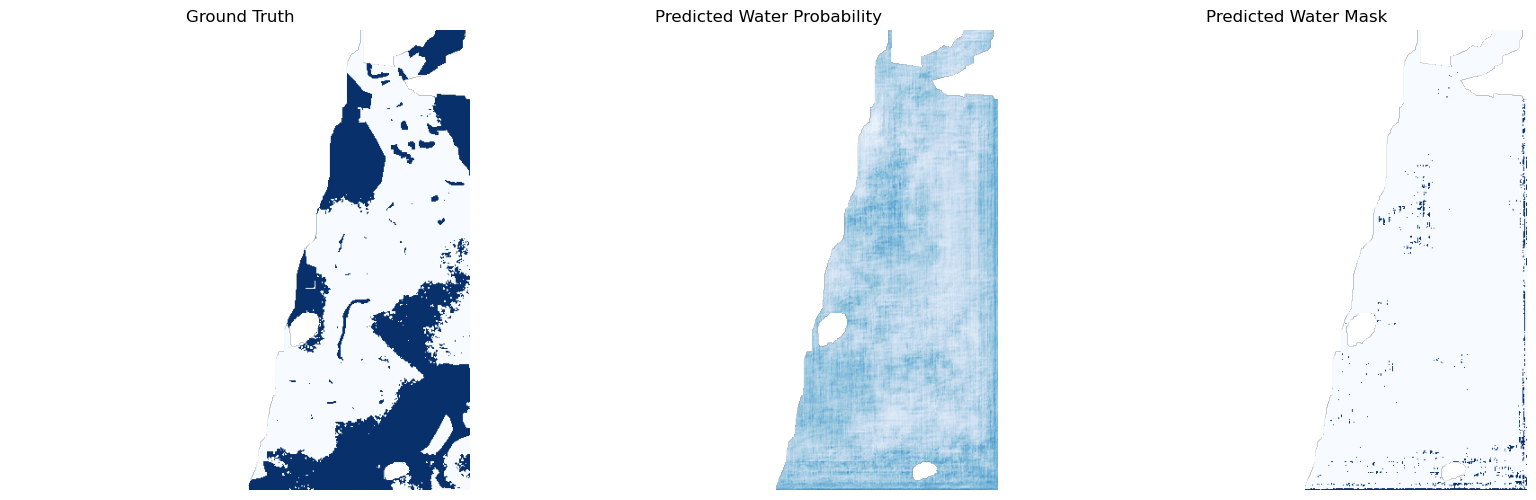

In [ ]:
# Hide invalid pixels in the visualizations
ground_truth_display = numpy.where(valid_mask, water_pixel, numpy.nan)
prediction_display = numpy.where(valid_mask, pred_mask, numpy.nan)
probability_display = numpy.where(valid_mask, prob_map, numpy.nan)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].imshow(ground_truth_display, cmap="Blues", vmin=0, vmax=1)
axes[0].set_title("Ground Truth")

axes[1].imshow(probability_display, cmap="Blues", vmin=0, vmax=1)
axes[1].set_title("Predicted Water Probability")

axes[2].imshow(prediction_display, cmap="Blues", vmin=0, vmax=1)
axes[2].set_title("Predicted Water Mask")

for ax in axes:
    ax.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
# Only evaluate valid pixels
pred_water = (pred_mask == 1) & valid_mask
true_water = (water_pixel == 1) & valid_mask

intersection = numpy.logical_and(pred_water, true_water).sum()
union = numpy.logical_or(pred_water, true_water).sum()

iou = intersection / union if union > 0 else float("nan")

print(f"Water IoU: {iou:.4f}")

Water IoU: 0.0242
